# Bean

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

train_path = 'Dry_Bean_Dataset/dry_bean_train.csv'
test_path = 'Dry_Bean_Dataset/dry_bean_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

target_col = 'class'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class_names = label_encoder.classes_


preprocessor = StandardScaler()

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [17]:
# --- MÔ HÌNH 1: LOGISTIC REGRESSION ---
# Cài đặt max_iter lớn (ví dụ: 1000) để đảm bảo thuật toán tối ưu Gradient Descent hội tụ trên tập dữ liệu đa chiều
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_encoded)
y_pred_log = log_reg.predict(X_test_scaled)

# --- MÔ HÌNH 2: K-NEAREST NEIGHBORS (KNN) ---
# Lựa chọn K = 5 làm baseline chuẩn
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2) # p=2 tương đương khoảng cách Euclidean
knn.fit(X_train_scaled, y_train_encoded)
y_pred_knn = knn.predict(X_test_scaled)

# --- TÍNH TOÁN CÁC CHỈ SỐ (Sử dụng average='macro' cho bài toán đa lớp) ---
metrics_multiclass = {
    'Chỉ số (Macro Average)': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Logistic Regression': [
        accuracy_score(y_test_encoded, y_pred_log),
        precision_score(y_test_encoded, y_pred_log, average='macro'),
        recall_score(y_test_encoded, y_pred_log, average='macro'),
        f1_score(y_test_encoded, y_pred_log, average='macro')
    ],
    'K-Nearest Neighbors (KNN)': [
        accuracy_score(y_test_encoded, y_pred_knn),
        precision_score(y_test_encoded, y_pred_knn, average='macro'),
        recall_score(y_test_encoded, y_pred_knn, average='macro'),
        f1_score(y_test_encoded, y_pred_knn, average='macro')
    ]
}

df_compare_bean = pd.DataFrame(metrics_multiclass)
print("BẢNG SO SÁNH CHỈ SỐ ĐÁNH GIÁ TRÊN DRY BEAN DATASET:")
print(df_compare_bean.to_string(index=False))

BẢNG SO SÁNH CHỈ SỐ ĐÁNH GIÁ TRÊN DRY BEAN DATASET:
Chỉ số (Macro Average)  Logistic Regression  K-Nearest Neighbors (KNN)
              Accuracy             0.919158                   0.915467
             Precision             0.930725                   0.928993
                Recall             0.930049                   0.925628
              F1-score             0.930237                   0.927027


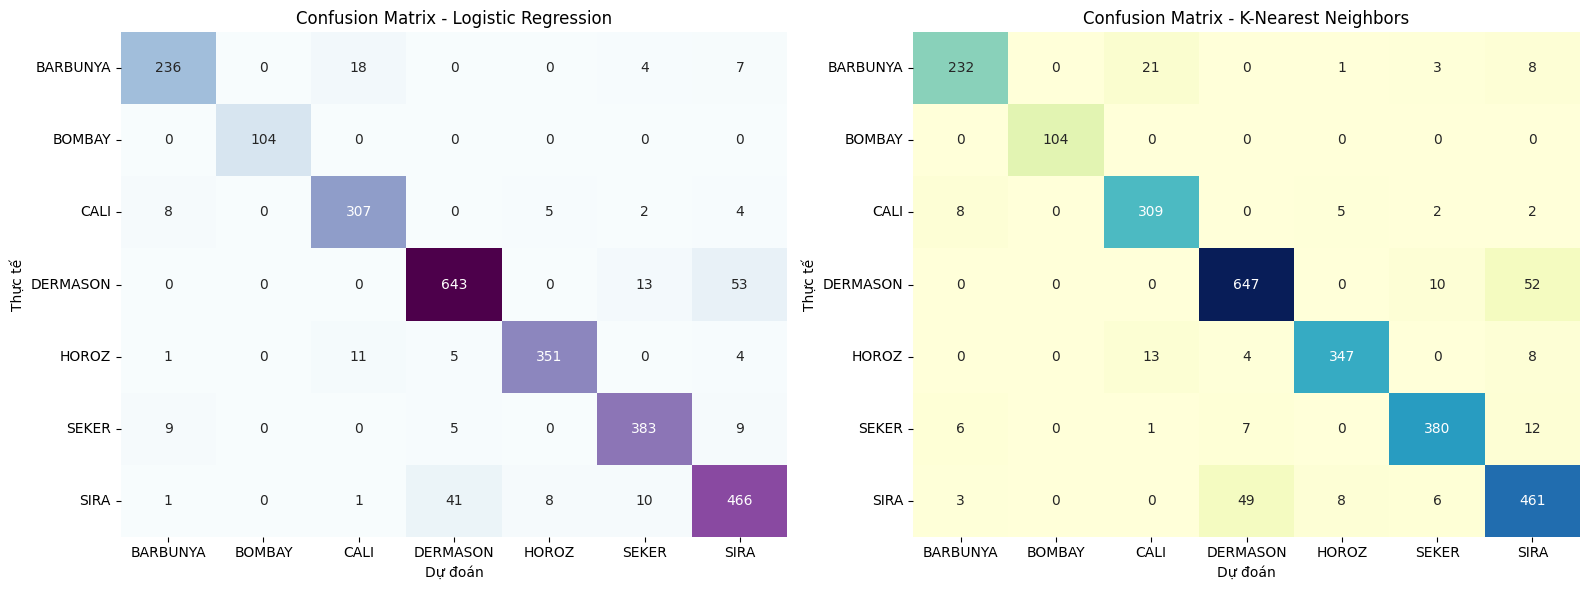

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression
cm_log_bean = confusion_matrix(y_test_encoded, y_pred_log)
sns.heatmap(cm_log_bean, annot=True, fmt='d', cmap='BuPu', ax=axes[0], cbar=False,
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

# KNN
cm_knn_bean = confusion_matrix(y_test_encoded, y_pred_knn)
sns.heatmap(cm_knn_bean, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1], cbar=False,
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Confusion Matrix - K-Nearest Neighbors')
axes[1].set_ylabel('Thực tế')
axes[1].set_xlabel('Dự đoán')

plt.tight_layout()
plt.show()

* **Ưu tiên Tốc độ dự đoán (Inference Time) $\rightarrow$ Logistic Regression:**
* **Ưu tiên Khớp ranh giới phức tạp (Boundary Fit) $\rightarrow$ KNN:**